<a href="https://colab.research.google.com/github/AnneSevero/AnneSevero/blob/main/An%C3%A1lise_Preditiva_de_Clientes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== CLIENTES (SQL) ===
   id_cliente       nome  idade  renda categoria
0           1  Cliente_1     56  13576      Ouro
1           2  Cliente_2     69   1564    Bronze
2           3  Cliente_3     46   9506     Prata
3           4  Cliente_4     32   4068    Bronze
4           5  Cliente_5     60   6963    Bronze

=== VENDAS (SQL) ===
   id_venda  id_cliente   valor  quantidade dia_semana
0         1          99  436.79           8        Ter
1         2          89  604.93           3        Sab
2         3          99  732.27           2        Ter
3         4          25  476.42           3        Seg
4         5          93  586.37           5        Dom

=== INTERAÇÕES (MongoDB Simulado) ===
   id_cliente                acao produto           timestamp
0          99               busca  Feijão 2024-01-01 00:00:00
1          41           favoritou   Arroz 2024-01-01 01:00:00
2           6              clique   Leite 2024-01-01 02:00:00
3          25  adicionou_carrinho  Açúcar 20

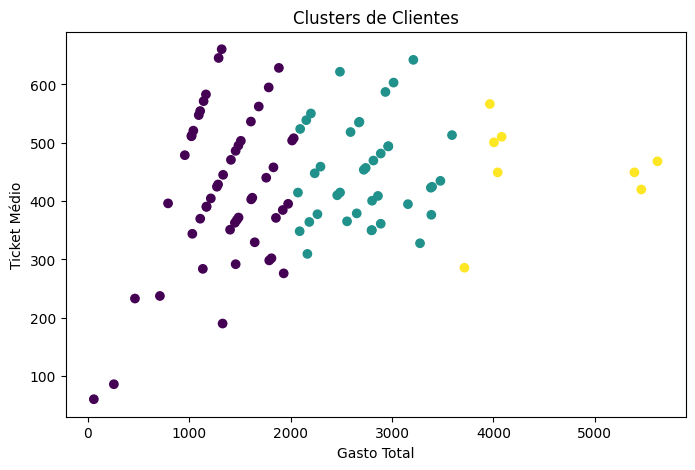


Clientes para regressão: 98

Coeficientes da Regressão:
[-6.80138289e+00 -2.24454342e-03]
Intercepto: 2448.4490187647943

Rede Neural treinada! Loss final: 6453175.0

Documento MongoDB simulando envio com anonimização gerado!

Prévia do documento:
    gasto_total  num_compras  ticket_medio  cluster id_cliente_anon
0       2557.30            7    365.328571        1          user_1
7       1784.81            3    594.936667        0          user_2
10      1165.86            2    582.930000        0          user_3
12      1458.53            3    486.176667        0          user_4
15      2031.20            4    507.800000        0          user_5


In [9]:
#O código precisou ser ajustado em algumas partes para que gerasse o resultado esperado#
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow import keras

np.random.seed(42)

# ============================================================
# 1. GERAÇÃO DOS DADOS FICTÍCIOS (SQL + NoSQL integrados)
# ============================================================

clientes = pd.DataFrame({
    "id_cliente": np.arange(1, 101),
    "nome": [f"Cliente_{i}" for i in range(1, 101)],
    "idade": np.random.randint(18, 70, 100),
    "renda": np.random.randint(1500, 15000, 100),
    "categoria": np.random.choice(["Bronze", "Prata", "Ouro"], 100)
})

vendas = pd.DataFrame({
    "id_venda": np.arange(1, 501),
    "id_cliente": np.random.randint(1, 101, 500),
    "valor": np.random.uniform(20, 800, 500).round(2),
    "quantidade": np.random.randint(1, 12, 500),
    "dia_semana": np.random.choice(
        ["Seg", "Ter", "Qua", "Qui", "Sex", "Sab", "Dom"],
        500
    )
})

# Base NoSQL simulada (MongoDB)
interacoes = pd.DataFrame({
    "id_cliente": np.random.randint(1, 101, 800),
    "acao": np.random.choice(
        ["clique", "busca", "favoritou", "adicionou_carrinho"],
        800
    ),
    "produto": np.random.choice(
        ["Arroz", "Feijão", "Café", "Açúcar", "Leite"],
        800
    ),
    "timestamp": pd.date_range(
        "2024-01-01",
        periods=800,
        freq="h"
    )
})

print("=== CLIENTES (SQL) ===")
print(clientes.head())

print("\n=== VENDAS (SQL) ===")
print(vendas.head())

print("\n=== INTERAÇÕES (MongoDB Simulado) ===")
print(interacoes.head())

# ============================================================
# 2. CONSULTAS SQL SIMULADAS (via Pandas)
# ============================================================

df = clientes.merge(vendas, on="id_cliente")

gastos = df.groupby("id_cliente")["valor"].sum().reset_index()
gastos.rename(columns={"valor": "gasto_total"}, inplace=True)

# ============================================================
# 3. FEATURE ENGINEERING (Data Mining)
# ============================================================

df = df.merge(gastos, on="id_cliente")

df["num_compras"] = (
    df.groupby("id_cliente")["id_venda"]
    .transform("count")
)

df["ticket_medio"] = (
    df["gasto_total"] / df["num_compras"]
)

# ============================================================
# 4. CLUSTERIZAÇÃO (Machine Learning)
# ============================================================

cluster_data = df[
    ["id_cliente", "gasto_total", "num_compras", "ticket_medio"]
].drop_duplicates()

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_data["cluster"] = (
    kmeans.fit_predict(
        cluster_data[
            ["gasto_total", "num_compras", "ticket_medio"]
        ]
    )
)

plt.figure(figsize=(8, 5))
plt.scatter(
    cluster_data["gasto_total"],
    cluster_data["ticket_medio"],
    c=cluster_data["cluster"]
)

plt.xlabel("Gasto Total")
plt.ylabel("Ticket Médio")
plt.title("Clusters de Clientes")
plt.show()

# ============================================================
# 5. REGRESSÃO (Machine Learning)
# ============================================================

dados_regressao = clientes.merge(
    gastos,
    on="id_cliente",
    how="inner"
)

print("\nClientes para regressão:",
      len(dados_regressao))

X = dados_regressao[["idade", "renda"]]
y = dados_regressao["gasto_total"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

print("\nCoeficientes da Regressão:")
print(modelo_lr.coef_)
print("Intercepto:", modelo_lr.intercept_)

# ============================================================
# 6. MINI REDE NEURAL (Deep Learning)
# ============================================================

modelo_nn = keras.Sequential([
    keras.layers.Input(shape=(2,)),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(8, activation="relu"),
    keras.layers.Dense(1)
])

modelo_nn.compile(
    optimizer="adam",
    loss="mse"
)

historico = modelo_nn.fit(
    X_train,
    y_train,
    epochs=20,
    verbose=0
)

print(
    "\nRede Neural treinada! Loss final:",
    historico.history["loss"][-1]
)

# ============================================================
# 7. MONGO SIMULADO + LGPD
# ============================================================

documento_mongo = cluster_data.copy()

documento_mongo["id_cliente_anon"] = (
    documento_mongo["id_cliente"]
    .apply(lambda x: f"user_{x}")
)

documento_mongo = documento_mongo.drop(
    columns=["id_cliente"]
)

documento_mongo.to_json(
    "clientes_clusters_mongo.json",
    orient="records"
)

print(
    "\nDocumento MongoDB simulando envio com anonimização gerado!"
)

print("\nPrévia do documento:")
print(documento_mongo.head())